# Stage 08 Production Physics Verification

This notebook documents and verifies the completed Stage 08 detection-probability grid:

- `cache/08_pdet_grid_v1.h5`
- `cache/08_pdet_grid_summary.json`

The earlier pilot artifacts are retained in `cache/`, but the production artifact above is the Stage 09-facing selection-function input.

## Purpose Of Stage 08

Stage 08 turns the trap-finding and intensity-fit cuts into a reusable selection function. It asks:

> If a trap with lifetime `tau`, amplitude `A`, and measurement temperature `T` were present in the data, what is the probability that the analysis would detect and accept it?

The output is a marginalized detection grid:

`p_det(T, tau, A)`

The grid is marginalized over quadrant and measured local noise. There is intentionally no explicit sigma axis in the primary output. For each synthetic intensity point, Stage 08 draws local noise from Stage 03 exact `(T, quadrant, dtph)` trap-free samples when available. If exact samples are unavailable, it falls back to `(T, quadrant)` and records the fallback fraction.

## Production Run Summary

The production grid uses:

- `23` measurement temperatures
- `55` tau points from `2e-5 s` to `20 s`
- `35` amplitude points from `200 e-` to `15000 e-`
- `100` realizations per grid point
- April-only `200 K` handling

For `200 K`, the upstream HDF5 was not regenerated. Instead, Stage 08 applies the provenance decision locally: it uses the April 2-4 CCD2 sequence, filters Stage 03 `200 K` noise samples to April source FITS, and recomputes April-only `200 K` image-sigma thresholds inside the production script.

In [13]:
from pathlib import Path
import json

import h5py
import numpy as np


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "trap_completeness_method3" / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find repo root from current working directory")


repo = find_repo_root()
workspace = repo / "trap_completeness_method3"
cache = workspace / "cache"
h5_path = cache / "08_pdet_grid_v1.h5"
summary_path = cache / "08_pdet_grid_summary.json"

print("repo:", repo)
print("HDF5:", h5_path, h5_path.exists())
print("JSON:", summary_path, summary_path.exists())

repo: c:\Users\Ansh\Projects\sensei_charge_traps
HDF5: c:\Users\Ansh\Projects\sensei_charge_traps\trap_completeness_method3\cache\08_pdet_grid_v1.h5 True
JSON: c:\Users\Ansh\Projects\sensei_charge_traps\trap_completeness_method3\cache\08_pdet_grid_summary.json True


In [25]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib import colors
from matplotlib import cm, ticker

# plotting specifications
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

smaller= 20
small = 24
medium = 30
large = 36

params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
plt.rcParams['figure.figsize']=(5,5)
plt.rcParams['axes.formatter.use_mathtext']=True

## Load Summary Metadata

In [14]:
with summary_path.open("r", encoding="utf-8") as handle:
    summary = json.load(handle)

for key in ["producing_stage", "produced_at", "random_seed", "realizations_per_grid_point", "shape", "runtime"]:
    print(f"{key}: {summary[key]}")

producing_stage: 08_full_pdet_grid
produced_at: 2026-05-22T13:01:13-07:00
random_seed: 2026052209
realizations_per_grid_point: 100
shape: {'amplitude_count': 35, 'fits_main_grid': 4427500, 'grid_points': 44275, 'max_delay_count': 25, 'tau_count': 55, 'temperature_count': 23}
runtime: {'fits_per_second': 507.5827982779832, 'hdf5_size_mb': 1.0213260650634766, 'json_size_mb': 0.0138092041015625, 'wall_seconds': 8722.714826075}


## Required Checks

These checks should all pass before Stage 09 consumes the artifact.

In [15]:
summary["required_checks"]

{'all_23_measurement_temperatures_have_detection_grid': 'PASS',
 'april_only_200k_grid_and_image_sigma_applied': 'PASS',
 'controlling_cutflow_fractions_sum_to_one': 'PASS',
 'exact_and_fallback_noise_draw_counts_stored_by_temperature': 'PASS',
 'primary_grid_has_no_explicit_sigma_axis': 'PASS'}

In [16]:
assert all(value == "PASS" for value in summary["required_checks"].values())
assert all(value == "PASS" for value in summary["stop_conditions"].values())
print("All production checks passed.")

All production checks passed.


## Verify HDF5 Structure

The primary `p_det` array must be three-dimensional: `(temperature, tau, amplitude)`. There should be no primary sigma dimension.

In [17]:
with h5py.File(h5_path, "r") as h5:
    groups = list(h5.keys())
    result_datasets = list(h5["results"].keys())
    diagnostic_datasets = list(h5["diagnostics"].keys())
    p_det = h5["results/p_det"][:]
    p_det_sigma = h5["results/p_det_binomial_sigma"][:]
    temperatures = h5["grid/temperature_K"][:]
    tau_grid = h5["grid/tau_seconds"][:]
    amplitude_grid = h5["grid/amplitude_electrons"][:]
    delay_counts = h5["grid/delay_counts"][:]
    cut_labels = [item.decode() for item in h5["results/cut_labels"][:]]
    controlling = h5["results/controlling_cut_fraction"][:]
    fallback_fraction = h5["diagnostics/fallback_noise_fraction_by_temperature"][:]

print("groups:", groups)
print("result datasets:", result_datasets)
print("diagnostic datasets:", diagnostic_datasets)
print("p_det shape:", p_det.shape)
print("tau range/count:", tau_grid[0], tau_grid[-1], len(tau_grid))
print("A range/count:", amplitude_grid[0], amplitude_grid[-1], len(amplitude_grid))

assert p_det.shape == (23, 55, 35)
assert p_det.shape == (len(temperatures), len(tau_grid), len(amplitude_grid))
assert p_det.ndim == 3
print("Primary grid is p_det(T, tau, A).")

groups: ['diagnostics', 'grid', 'results']
result datasets: ['controlling_cut_count', 'controlling_cut_fraction', 'cut_labels', 'failed_cut_count', 'failed_cut_fraction', 'failed_cut_labels', 'p_det', 'p_det_binomial_sigma', 'pass_count']
diagnostic datasets: ['exact_noise_draw_count_by_temperature', 'exact_noise_draw_count_by_temperature_dtph', 'fallback_noise_draw_count_by_temperature', 'fallback_noise_draw_count_by_temperature_dtph', 'fallback_noise_fraction_by_temperature', 'quadrant_draw_count']
p_det shape: (23, 55, 35)
tau range/count: 2e-05 20.0 55
A range/count: 200.0 15000.0 35
Primary grid is p_det(T, tau, A).


## Verify Temperature Coverage And April-Only 200 K

In [18]:
expected_temps = [125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 183, 185, 187, 190, 193, 195, 197, 200, 203, 207, 210]
delay_by_temp = {int(t): int(c) for t, c in zip(temperatures, delay_counts)}

print(delay_by_temp)
assert temperatures.tolist() == expected_temps
assert delay_by_temp[200] == 25
assert max(delay_by_temp.values()) == 25
print("Temperature coverage and April-only 200 K delay grid are correct.")

{125: 18, 130: 18, 135: 18, 140: 18, 145: 18, 150: 18, 155: 18, 160: 18, 165: 18, 170: 18, 175: 18, 180: 25, 183: 25, 185: 18, 187: 25, 190: 25, 193: 25, 195: 18, 197: 25, 200: 25, 203: 25, 207: 25, 210: 18}
Temperature coverage and April-only 200 K delay grid are correct.


In [19]:
summary["model_choice"]["temperature_200_selection"], summary["model_choice"]["temperature_200_image_sigma"]

('April-only CCD2 run IDs 160-184; upstream HDF5 was not regenerated.',
 {'dtphs': [750,
   1200,
   2000,
   3000,
   5000,
   8000,
   18000,
   28000,
   45000,
   70000,
   100000,
   170000,
   260000,
   400000,
   650000,
   1000000,
   1500000,
   1800000,
   2000000,
   2500000,
   3500000,
   6500000,
   8500000,
   10500000,
   15500000],
  'file_count': 25,
  'median_image_sigma_by_quadrant': {'0': 155.93408179415928,
   '1': 196.00469610936622,
   '2': 209.18728849102087,
   '3': 165.40168584137803},
  'method': 'Recomputed from April-only 200 K CCD2 proc FITS using getDipoleSpectra2 image_sigma statistic.',
  'per_quadrant_summary': {'0': {'count': 25,
    'max': 249.7996174897852,
    'mean': 161.33487293954056,
    'median': 155.93408179415928,
    'min': 140.71199973903293,
    'p05': 143.04956235060018,
    'p16': 146.46215964423408,
    'p84': 164.85240304021934,
    'p95': 203.29749052097085,
    'std': 23.179817134523958},
   '1': {'count': 25,
    'max': 274.51059

## Verify Noise Draw Accounting

Fallback should be zero for this production run: exact Stage 03 `(T, quadrant, dtph)` noise samples exist for all grid points after April-only 200 K filtering.

In [20]:
fallback = summary["fallback_noise_by_temperature"]
for temp in sorted(fallback, key=int):
    row = fallback[temp]
    assert row["exact_noise_draw_count"] > 0
    assert row["fallback_noise_draw_count"] == 0
    assert row["fallback_noise_fraction"] == 0.0

print("Max fallback fraction from HDF5:", float(np.max(fallback_fraction)))
assert float(np.max(fallback_fraction)) == 0.0

Max fallback fraction from HDF5: 0.0


## Verify Cutflow Accounting

The controlling-cut fractions should sum to one at every grid point.

In [21]:
cut_sum = controlling.sum(axis=-1)
max_dev = float(np.max(np.abs(cut_sum - 1.0)))
print(cut_labels)
print("max cutflow sum deviation:", max_dev)
assert max_dev < 1e-12

['pass', 'fit_failed', 'p_value', 'max_intensity_lt_3_mean_intensity_err', 'max_intensity_lt_3_image_sigma', 'tau_relative_error_gt_0p5']
max cutflow sum deviation: 2.220446049250313e-16


## Production Physics Takeaways

The completed grid behaves as expected for a selection function:

- It has hard low-efficiency regions where traps are too faint, too short-lived relative to the sampled grid, or only visible as weak long-tau rising edges.
- It has high-efficiency regions for bright traps whose peak is reachable by the measurement grid.
- The dominant non-pass cuts are physically interpretable: peak below `3 * mean(intensity_err)`, tau uncertainty, chi-square p-value, and peak below image-sigma threshold.
- Fit failures are essentially negligible globally.
- Exact noise draws were available everywhere, so the production grid is driven by measured local noise rather than fallback pools.

Headline numbers from the production summary are printed below.

In [22]:
for key in [
    "p_det_summary",
    "p_det_binomial_sigma_summary",
    "dominant_controlling_cut_fractions",
]:
    print("\n" + key)
    print(json.dumps(summary[key], indent=2, sort_keys=True))


p_det_summary
{
  "count": 44275,
  "max": 1.0,
  "mean": 0.5059105590062112,
  "median": 0.6,
  "min": 0.0,
  "p05": 0.0,
  "p16": 0.0,
  "p84": 0.96,
  "p95": 0.97,
  "std": 0.43370523094328717
}

p_det_binomial_sigma_summary
{
  "count": 44275,
  "max": 0.05,
  "mean": 0.02059424296206216,
  "median": 0.021794494717703367,
  "min": 0.0,
  "p05": 0.0,
  "p16": 0.0,
  "p84": 0.03469870314579494,
  "p95": 0.048,
  "std": 0.013947241170432003
}

dominant_controlling_cut_fractions
{
  "fit_failed": 6.775832862789384e-07,
  "max_intensity_lt_3_image_sigma": 0.046494184076792774,
  "max_intensity_lt_3_mean_intensity_err": 0.3062748729531338,
  "p_value": 0.05758735177865613,
  "pass": 0.5059105590062112,
  "tau_relative_error_gt_0p5": 0.08373235460191981
}


## Quick-Look Maps

These plots are for visual QA. Stage 09 should use the HDF5 arrays directly.

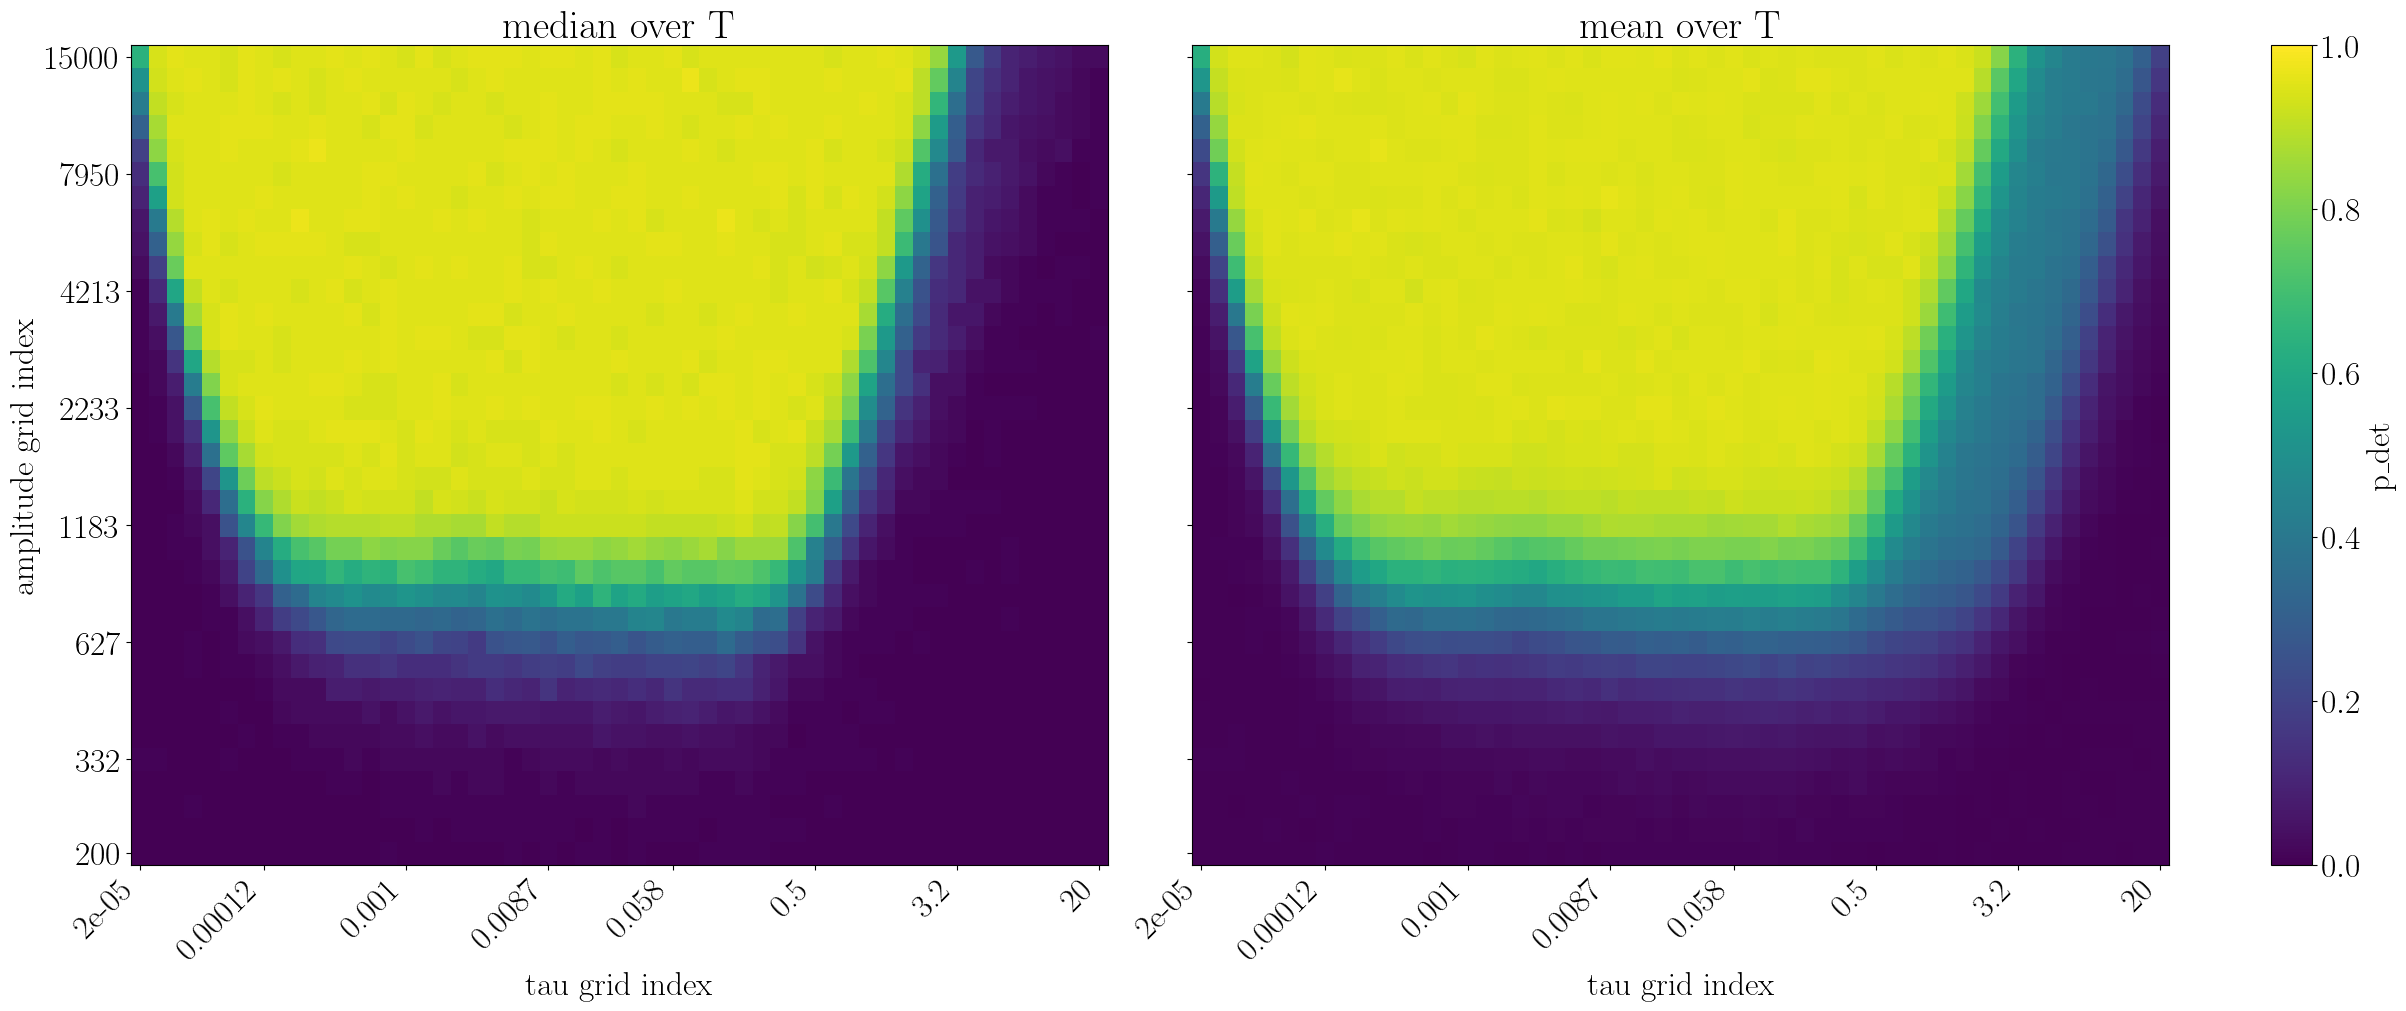

In [39]:
import matplotlib.pyplot as plt

median_over_temp = np.median(p_det, axis=0)
mean_over_temp = np.mean(p_det, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(24, 10), sharey=True,constrained_layout=True)
for ax, data, title in zip(axes, [median_over_temp, mean_over_temp], ["median over T", "mean over T"]):
    im = ax.imshow(data.T, origin="lower", aspect="auto", vmin=0, vmax=1)
    ax.set_xlabel("tau grid index")
    ax.set_title(title)
    ax.set_xticks(np.linspace(0, len(tau_grid) - 1, 8, dtype=int))
    ax.set_xticklabels([f"{tau_grid[i]:.2g}" for i in ax.get_xticks()], rotation=45, ha="right")
axes[0].set_ylabel("amplitude grid index")
axes[0].set_yticks(np.linspace(0, len(amplitude_grid) - 1, 8, dtype=int))
axes[0].set_yticklabels([f"{amplitude_grid[i]:.0f}" for i in axes[0].get_yticks()])
fig.colorbar(im, ax=axes.tolist(), label="p_det")
# fig.suptitle("")
# fig.tight_layout()

## Temperature Slices

Inspect representative cold, middle, April-only `200 K`, and warm temperatures.

C:\Users\Ansh\AppData\Local\Temp\ipykernel_162008\439673514.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


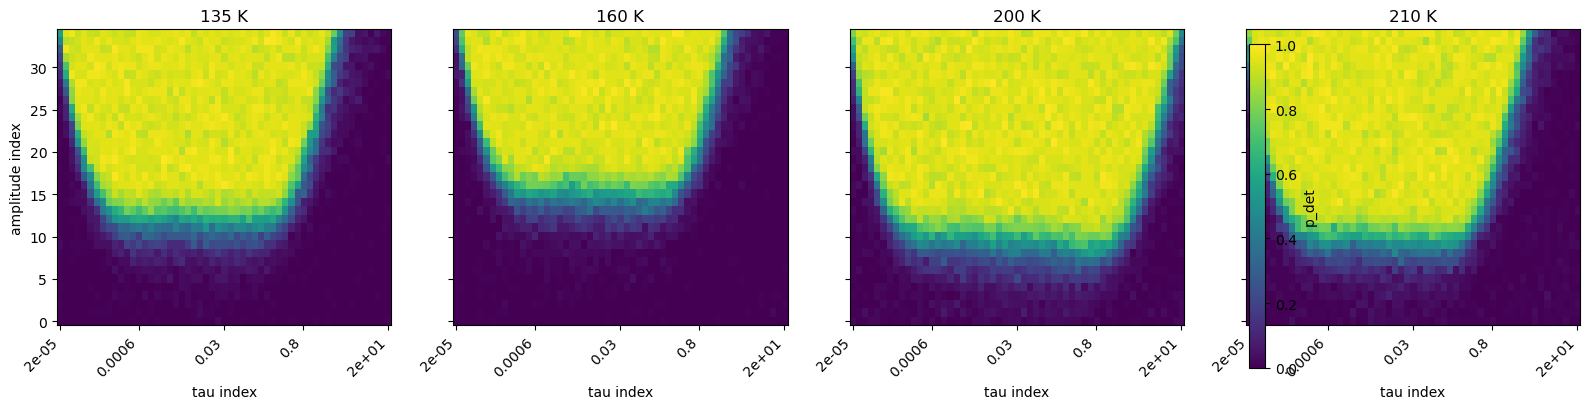

In [12]:
slice_temps = [135, 160, 200, 210]
fig, axes = plt.subplots(1, len(slice_temps), figsize=(4.0 * len(slice_temps), 4.2), sharey=True)
for ax, temp in zip(axes, slice_temps):
    ti = int(np.flatnonzero(temperatures == temp)[0])
    im = ax.imshow(p_det[ti].T, origin="lower", aspect="auto", vmin=0, vmax=1)
    ax.set_title(f"{temp} K")
    ax.set_xlabel("tau index")
    ax.set_xticks(np.linspace(0, len(tau_grid) - 1, 5, dtype=int))
    ax.set_xticklabels([f"{tau_grid[i]:.1g}" for i in ax.get_xticks()], rotation=45, ha="right")
axes[0].set_ylabel("amplitude index")
fig.colorbar(im, ax=axes, label="p_det")
fig.tight_layout()

## Human Review Checklist Before Stage 09

- Use `cache/08_pdet_grid_v1.h5`, not the pilot artifact.
- Preserve the April-only `200 K` provenance note in Stage 09 metadata.
- Decide whether uniform quadrant marginalization is acceptable for the characterization-probability model.
- Inspect interpolation behavior in Stage 09, especially at sharp peak-threshold transitions.
- Keep the production grid's binomial uncertainty in mind: median `~0.022`, max `0.05` for `100` realizations per grid point.